In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/emilygarrard/Desktop/qss20/HMS_2024-2025_PUBLIC_instchars.csv")

/var/folders/41/r1r1sw3s32991v4p879m3brr0000gn/T/ipykernel_25827/2651984103.py:6: DtypeWarning: Columns (13,25,53,54,55,56,57,58,59,60,881,1475,1590) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/emilygarrard/Desktop/qss20/HMS_2024-2025_PUBLIC_instchars.csv")


In [9]:
# build composite scores
phq9_items = [f"phq9_{i}" for i in range(1, 10)]
gad7_items = [f"gad7_{i}" for i in range(1, 8)]

# subtract 1 from each item to convert 1-4 coding back to 0-3 (official scoring)
df["phq9_total"] = (df[phq9_items] - 1).sum(axis=1, min_count=9)
df["gad7_total"] = (df[gad7_items] - 1).sum(axis=1, min_count=7)

# screening flag with 10 as standard clinical cutoff
df["depression_screen"] = (df["phq9_total"] >= 10).astype(int)
df["anxiety_screen"] = (df["gad7_total"] >= 10).astype(int)
# drop NaNs
df.loc[df["phq9_total"].isna(), "depression_screen"] = pd.NA
df.loc[df["gad7_total"].isna(), "anxiety_screen"] = pd.NA

In [10]:
# gender condition
conditions = [
    df["gender_nonbin"] == 1,
    df["gender_trans"] == 1,
    df["gender_queer"] == 1,
    df["gender_female"] == 1,
    df["gender_male"] == 1,
    df["gender_selfID"] == 1,
]
choices = ["Nonbinary", "Trans", "Genderqueer", "Woman", "Man", "Self-described"]

df["gender"] = np.select(conditions, choices, default=None)

In [11]:
# pull relevant columns
working_cols = [
    # identifiers and demographics
    "responseid", "age", "gender",
    # mental health scores and screens
    "phq9_total", "gad7_total", "depression_screen", "anxiety_screen",
    # loneliness items
    "lonesc", "lonely",
    "lone_lackcompanion", "lone_leftout", "lone_isolated",
    # stress items
    "FinStress", "stress1", "stress2", "stress3", "stress4",
    # sexual orientation items
    "sexual_h", "sexual_l", "sexual_g", "sexual_bi", "sexual_queer",
    "sexual_quest", "sexual_pan", "sexual_asexual", "sexual_selfID", 
    # race items
    "race_black", "race_ainaan", "race_asian", "race_his", 
    "race_pi", "race_mides", "race_white", "race_other", 
    # belonging items
    "belong1", "belong2", "belong8", "belong9",
    # stigma items
    "stig_per_1", "stig_per_2", "stig_per_3",
    "stig_pcv_1", "stig_pcv_2", "stig_pcv_3",
    "stig_self_1", "stig_self_2", "stig_self_3"]

my_cols = df[working_cols].copy()

print("Working dataset:", my_cols.shape)

Working dataset: (84735, 47)


In [18]:
# filter to emerging adults (18-24)
emerging_adults = my_cols[my_cols["age"].between(18, 24)].copy()
print("Emerging adults (18-24):", len(emerging_adults))

print("Mental health summary, emerging adults (18-24):\n")
print(emerging_adults[["phq9_total", "gad7_total", "lonesc"]].describe().round(2))

print("\nClinical screening rates:")
dep_rate = (emerging_adults["phq9_total"] >= 10).mean() * 100
anx_rate = (emerging_adults["gad7_total"] >= 10).mean() * 100
lone_rate = (emerging_adults["lonesc"] >= 6).mean() * 100

print(f"  % screening positive for depression (PHQ-9 ≥ 10): {dep_rate:.1f}%")
print(f"  % screening positive for anxiety   (GAD-7 ≥ 10): {anx_rate:.1f}%")
print(f"  % lonely (UCLA-3 score ≥ 6):                      {lone_rate:.1f}%")

dep_anx = emerging_adults["phq9_total"].corr(emerging_adults["gad7_total"])
dep_lone = emerging_adults["phq9_total"].corr(emerging_adults["lonesc"])
anx_lone = emerging_adults["gad7_total"].corr(emerging_adults["lonesc"])

print("\nCorrelations between depression, anxiety, and loneliness:")
print(f"  Depression & Anxiety:    r = {dep_anx:.3f}")
print(f"  Depression & Loneliness: r = {dep_lone:.3f}")
print(f"  Anxiety & Loneliness:    r = {anx_lone:.3f}")

Emerging adults (18-24): 61288
Mental health summary, emerging adults (18-24):

       phq9_total  gad7_total    lonesc
count    52314.00    51952.00  52717.00
mean         8.40        7.61      5.54
std          6.22        5.78      1.94
min          0.00        0.00      3.00
25%          3.00        3.00      4.00
50%          7.00        7.00      6.00
75%         12.00       12.00      7.00
max         27.00       21.00      9.00

Clinical screening rates:
  % screening positive for depression (PHQ-9 ≥ 10): 31.6%
  % screening positive for anxiety   (GAD-7 ≥ 10): 28.8%
  % lonely (UCLA-3 score ≥ 6):                      44.2%

Correlations between depression, anxiety, and loneliness:
  Depression & Anxiety:    r = 0.741
  Depression & Loneliness: r = 0.541
  Anxiety & Loneliness:    r = 0.473


In [13]:
# give description to loneliness scores
loneliness_des = {
    3: "Not lonely",
    4: "Barely lonely",
    5: "Slightly lonely",
    6: "Moderately lonely",
    7: "Quite lonely",
    8: "Very lonely",
    9: "Extremely lonely"}

emerging_adults["loneliness_label"] = emerging_adults["lonesc"].replace(loneliness_des)

label_order = ["Not lonely", "Barely lonely", "Slightly lonely", "Moderately lonely",
               "Quite lonely", "Very lonely", "Extremely lonely"]

In [ ]:
# plot mental health by loneliness

# create side by side plots of depression and anxiety by loneliness
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# depression plot
sns.barplot(data=emerging_adults, x="loneliness_label", y="phq9_total",
            order=label_order, ax=axes[0], color="steelblue", errorbar="ci")
axes[0].axhline(10, color="red", linestyle="--", alpha=0.5, label="Clinical threshold")
axes[0].set_title("Depression (PHQ-9) by Loneliness")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean PHQ-9 score")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# anxiety plot
sns.barplot(data=emerging_adults, x="loneliness_label", y="gad7_total",
            order=label_order, ax=axes[1], color="coral", errorbar="ci")
axes[1].axhline(10, color="red", linestyle="--", alpha=0.5, label="Clinical threshold")
axes[1].set_title("Anxiety (GAD-7) by Loneliness")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean GAD-7 score")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle("Mental Health by Loneliness — Emerging Adults (HMS 2024-25)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("mental_health_by_loneliness.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
minority_cols = ["sexual_l", "sexual_g", "sexual_bi", "sexual_queer",
                 "sexual_quest", "sexual_pan", "sexual_asexual"]

marked_straight = emerging_adults["sexual_h"] == 1
marked_minority = (emerging_adults[minority_cols] == 1).any(axis=1)

emerging_adults["sexual_orientation_binary"] = np.select(
    [marked_minority, marked_straight & ~marked_minority],
    ["Sexual minority", "Heterosexual"],
    default=None)

print(emerging_adults["sexual_orientation_binary"].value_counts(dropna=False))

sexual_orientation_binary
Heterosexual       37657
Sexual minority    19434
None                4197
Name: count, dtype: int64


In [10]:
conditions = [
    emerging_adults["sexual_bi"] == 1,
    emerging_adults["sexual_pan"] == 1,
    emerging_adults["sexual_l"] == 1,
    emerging_adults["sexual_g"] == 1,
    emerging_adults["sexual_queer"] == 1,
    emerging_adults["sexual_asexual"] == 1,
    emerging_adults["sexual_quest"] == 1,
    emerging_adults["sexual_selfID"] == 1,
    emerging_adults["sexual_h"] == 1,
]
choices = ["Bisexual", "Pansexual", "Lesbian", "Gay", "Queer",
           "Asexual", "Questioning", "Self-described", "Heterosexual"]
emerging_adults["sexual_orientation"] = np.select(conditions, choices, default=None)
print(emerging_adults["sexual_orientation"].value_counts(dropna=False))

print("\nMean loneliness score by sexual orientation:")
print(emerging_adults.groupby("sexual_orientation")["lonesc"]
      .agg(["mean", "median", "count"]).round(2)
      .sort_values("mean"))

print("\nMental health metrics by sexual orientation:")
print(emerging_adults.groupby("sexual_orientation")[["lonesc", "phq9_total", "gad7_total"]]
      .mean().round(2)
      .sort_values("lonesc"))

sexual_orientation
Heterosexual      37593
Bisexual           9446
None               3529
Lesbian            2283
Queer              2165
Pansexual          1780
Asexual            1273
Gay                1247
Questioning        1240
Self-described      732
Name: count, dtype: int64

Mean loneliness score by sexual orientation:
                    mean  median  count
sexual_orientation                     
Heterosexual        5.23     5.0  32373
Self-described      5.52     6.0    588
Gay                 5.96     6.0   1125
Lesbian             5.99     6.0   2055
Asexual             6.02     6.0   1179
Bisexual            6.08     6.0   8438
Questioning         6.24     6.0   1116
Queer               6.30     6.0   1984
Pansexual           6.40     6.0   1610

Mental health metrics by sexual orientation:
                    lonesc  phq9_total  gad7_total
sexual_orientation                                
Heterosexual          5.23        7.23        6.66
Self-described        5.52    

sm_status
Heterosexual       37593
Sexual minority    20166
None                3529
Name: count, dtype: int64


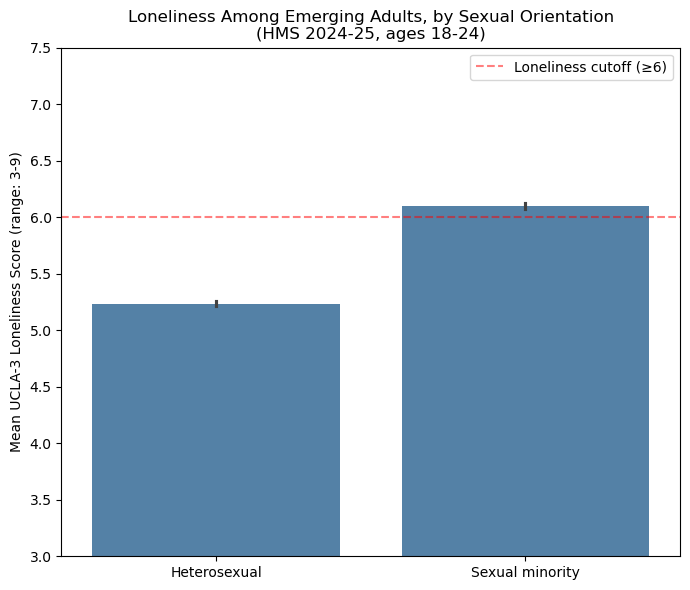

In [11]:
# create binary sexual orientation variable (heterosexual vs. sexual minority)
emerging_adults["sm_status"] = np.where(
    emerging_adults["sexual_orientation"] == "Heterosexual",
    "Heterosexual",
    "Sexual minority")

# people with no sexual_orientation value
emerging_adults.loc[emerging_adults["sexual_orientation"].isna(), "sm_status"] = None

print(emerging_adults["sm_status"].value_counts(dropna=False))

# plot loneliness by sexual minority status
plt.figure(figsize=(7, 6))
sns.barplot(data=emerging_adults, x="sm_status", y="lonesc",
            order=["Heterosexual", "Sexual minority"],
            color="steelblue", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness Among Emerging Adults, by Sexual Orientation\n(HMS 2024-25, ages 18-24)")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (range: 3-9)")
plt.ylim(3, 7.5)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# classify racial minority status
non_white_cols = ["race_black", "race_ainaan", "race_asian", 
                  "race_his", "race_pi", "race_mides", "race_other"]

marked_non_white = (emerging_adults[non_white_cols] == 1).any(axis=1)
marked_white = emerging_adults["race_white"] == 1

emerging_adults["race_status"] = np.select(
    [marked_non_white, marked_white & ~marked_non_white],
    ["Racial minority", "White"],
    default=None
)

print(emerging_adults["race_status"].value_counts(dropna=False))

race_status
White              30381
Racial minority    29891
None                1016
Name: count, dtype: int64


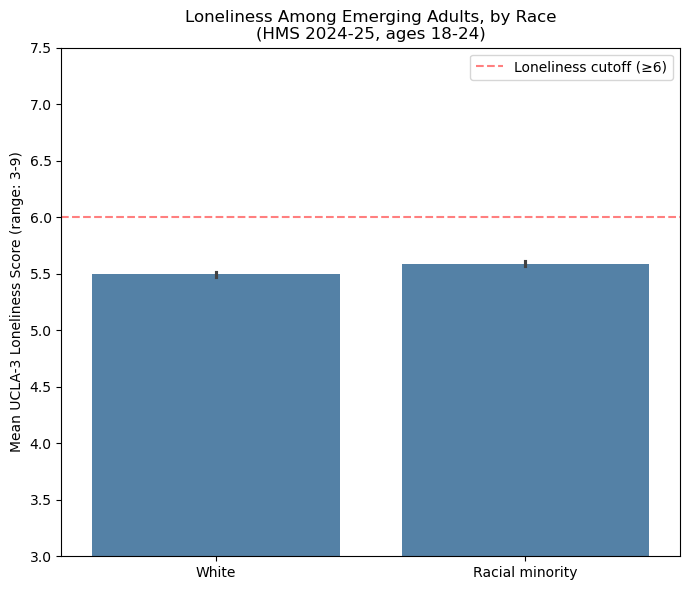

In [13]:
# plot loneliness by race
plt.figure(figsize=(7, 6))
sns.barplot(data=emerging_adults, x="race_status", y="lonesc",
            order=["White", "Racial minority"],
            color="steelblue", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness Among Emerging Adults, by Race\n(HMS 2024-25, ages 18-24)")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (range: 3-9)")
plt.ylim(3, 7.5)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# belonging — reverse-code items so higher = more belonging across all items
belong_items = ["belong1", "belong2", "belong8", "belong9"]

print("Response options for each belonging item:")
for c in belong_items:
    print(f"  {c}: {sorted(emerging_adults[c].dropna().unique())}")

# Reverse-code belong1 and belong2 (scale is 1-6, so flip with 7 - value)
for item in ["belong1", "belong2"]:
    emerging_adults[f"{item}_r"] = 7 - emerging_adults[item]

belong_corrected = ["belong1_r", "belong2_r", "belong8", "belong9"]
emerging_adults["belong_total"] = emerging_adults[belong_corrected].sum(axis=1, min_count=4)

# Verify all items correlate in the same direction with loneliness
print("\nItem correlations with loneliness:")
for item in belong_corrected:
    r = emerging_adults[item].corr(emerging_adults["lonesc"])
    print(f"  {item}: r = {r:+.3f}")

r_total = emerging_adults["belong_total"].corr(emerging_adults["lonesc"])
print(f"\nbelong_total × lonesc: r = {r_total:+.3f}")

Response options for each belonging item:
  belong1: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  belong2: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  belong8: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
  belong9: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]

Item correlations with loneliness:
  belong1_r: r = -0.329
  belong2_r: r = -0.470
  belong8: r = -0.507
  belong9: r = -0.308

belong_total × lonesc: r = -0.524


Mean loneliness by belonging category:

                    mean  median  count
belong_cat                             
Low belonging       6.52     6.0   9851
Moderate belonging  5.31     5.0   6611
High belonging      4.37     4.0   7629


/var/folders/41/r1r1sw3s32991v4p879m3brr0000gn/T/ipykernel_21299/1014262254.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


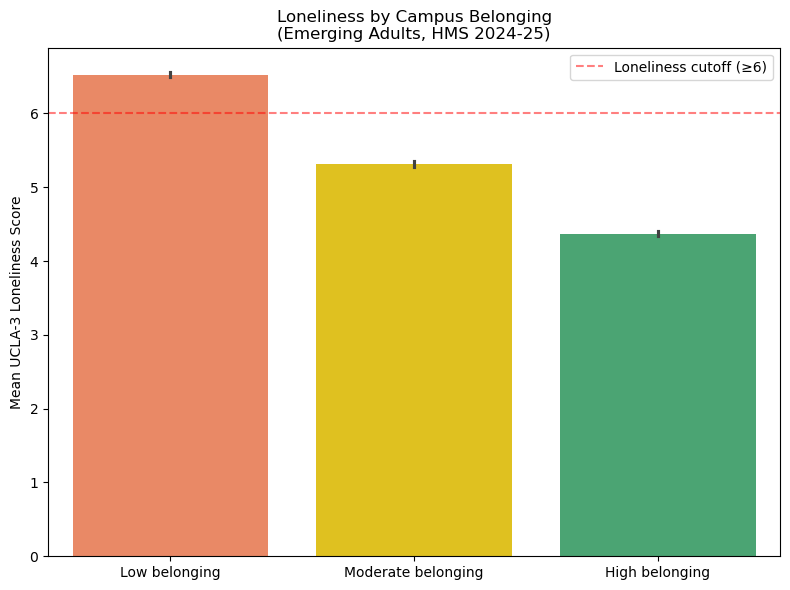

In [18]:
# belonging into thirds (low/moderate/high)
emerging_adults["belong_cat"] = pd.qcut(
    emerging_adults["belong_total"],
    q=3,
    labels=["Low belonging", "Moderate belonging", "High belonging"])

print("Mean loneliness by belonging category:\n")
print(emerging_adults.groupby("belong_cat", observed=True)["lonesc"]
      .agg(["mean", "median", "count"]).round(2))

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=emerging_adults.dropna(subset=["belong_cat"]),
    x="belong_cat",
    y="lonesc",
    order=["Low belonging", "Moderate belonging", "High belonging"],
    palette=["coral", "gold", "mediumseagreen"],
    errorbar="ci")

ax.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
ax.set_title("Loneliness by Campus Belonging\n(Emerging Adults, HMS 2024-25)")
ax.set_xlabel("")
ax.set_ylabel("Mean UCLA-3 Loneliness Score")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# stigma — reverse-code items so higher = more stigma across all scales
reverse_code_stigma = [
    "stig_per_1", "stig_per_2", "stig_per_3",
    "stig_pcv_1", "stig_pcv_3"]

for item in reverse_code_stigma:
    emerging_adults[f"{item}_r"] = 7 - emerging_adults[item]

# build composite scales (min_count ensures we don't sum incomplete responses)
personal_items = ["stig_per_1_r", "stig_per_2_r", "stig_per_3_r"]
perceived_items = ["stig_pcv_1_r", "stig_pcv_2", "stig_pcv_3_r"]
self_items = ["stig_self_1", "stig_self_2", "stig_self_3"]

emerging_adults["stigma_personal"] = emerging_adults[personal_items].sum(axis=1, min_count=3)
emerging_adults["stigma_perceived"] = emerging_adults[perceived_items].sum(axis=1, min_count=3)
emerging_adults["stigma_self"] = emerging_adults[self_items].sum(axis=1, min_count=3)

print("\nComposite scales with loneliness:")
for c in ["stigma_personal", "stigma_perceived", "stigma_self"]:
    r = emerging_adults[c].corr(emerging_adults["lonesc"])
    print(f"  {c}: r = {r:+.3f}")


Composite scales with loneliness:
  stigma_personal: r = +0.019
  stigma_perceived: r = +0.130
  stigma_self: r = +0.135


In [21]:
# both scales now go from 3 (lowest stigma) to 18 (highest stigma) on the recoded composites
personal_mean = emerging_adults["stigma_personal"].mean()
perceived_mean = emerging_adults["stigma_perceived"].mean()

print(f"Personal stigma   (avg of all students' OWN attitudes):     {personal_mean:.2f}")
print(f"Perceived stigma  (avg of what students THINK others believe): {perceived_mean:.2f}")
print(f"Gap (perceived − personal): {perceived_mean - personal_mean:.2f}")

Personal stigma   (avg of all students' OWN attitudes):     8.88
Perceived stigma  (avg of what students THINK others believe): 8.04
Gap (perceived − personal): -0.84


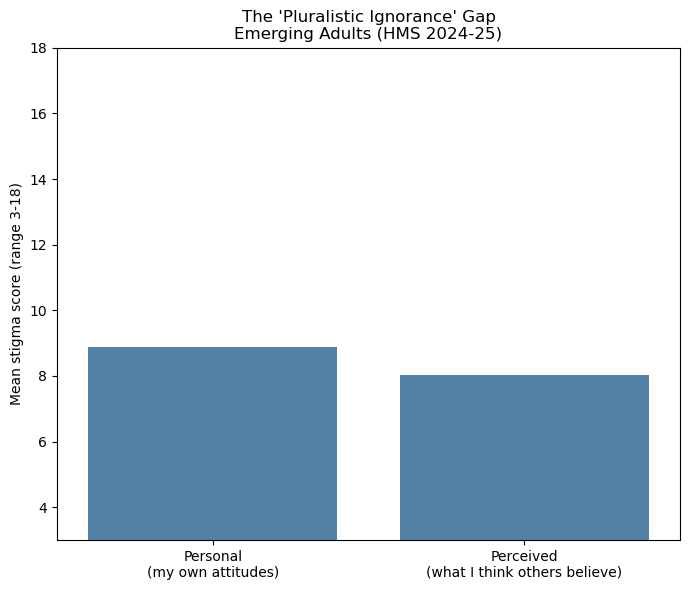

In [22]:
# reshape for plotting
stigma_data = pd.DataFrame({
    "Stigma type": ["Personal\n(my own attitudes)", "Perceived\n(what I think others believe)"],
    "Mean score": [personal_mean, perceived_mean]
})

# plot personal vs perceived stigma
plt.figure(figsize=(7, 6))
sns.barplot(data=stigma_data, x="Stigma type", y="Mean score", color="steelblue")
plt.title("The 'Pluralistic Ignorance' Gap\nEmerging Adults (HMS 2024-25)")
plt.xlabel("")
plt.ylabel("Mean stigma score (range 3-18)")
plt.ylim(3, 18)
plt.tight_layout()
plt.show()

In [27]:
# overall average for emerging adults (for reference)
overall_lone = emerging_adults["lonesc"].mean()
overall_phq = emerging_adults["phq9_total"].mean()
overall_gad = emerging_adults["gad7_total"].mean()

# averages within depression-positive subgroups
needs_help = emerging_adults[emerging_adults["phq9_total"] >= 10].copy()
needs_help["perceived_stigma_tertile"] = pd.qcut(
    needs_help["stigma_perceived"], 
    q=3, 
    labels=["Low perceived stigma", "Mid", "High perceived stigma"]
)
group_means = needs_help.groupby("perceived_stigma_tertile", observed=True)[
    ["lonesc", "phq9_total", "gad7_total"]
].mean().round(2)

# high vs low stigma for direct comparison
low_lone = group_means.loc["Low perceived stigma", "lonesc"]
high_lone = group_means.loc["High perceived stigma", "lonesc"]
low_phq = group_means.loc["Low perceived stigma", "phq9_total"]
high_phq = group_means.loc["High perceived stigma", "phq9_total"]
low_gad = group_means.loc["Low perceived stigma", "gad7_total"]
high_gad = group_means.loc["High perceived stigma", "gad7_total"]

print(f"The average emerging adult in this sample reports a loneliness "
      f"score of {overall_lone:.2f}, a PHQ-9 of {overall_phq:.2f}, and a GAD-7 of "
      f"{overall_gad:.2f}.\n")

print("Among students who screen positive for depression (PHQ-9 ≥ 10), all three groups "
      "have markedly worse outcomes than the overall average, as expected. But within "
      "this depression-positive subgroup, students who perceive their environment as "
      "more stigmatizing show consistently worse outcomes than those who perceive "
      "less stigma:\n")

print(f"• Loneliness rises from {low_lone} (low stigma) to {high_lone} (high stigma) "
      f"— a difference of {high_lone - low_lone:.2f} points on the 3-9 scale.")
print(f"• PHQ-9 depression rises from {low_phq} to {high_phq} "
      f"— a difference of {high_phq - low_phq:.2f} points on the 0-27 scale.")
print(f"• GAD-7 anxiety rises from {low_gad} to {high_gad} "
      f"— a difference of {high_gad - low_gad:.2f} points on the 0-21 scale.")

The average emerging adult in this sample reports a loneliness score of 5.54, a PHQ-9 of 8.40, and a GAD-7 of 7.61.

Among students who screen positive for depression (PHQ-9 ≥ 10), all three groups have markedly worse outcomes than the overall average, as expected. But within this depression-positive subgroup, students who perceive their environment as more stigmatizing show consistently worse outcomes than those who perceive less stigma:

• Loneliness rises from 6.56 (low stigma) to 6.88 (high stigma) — a difference of 0.32 points on the 3-9 scale.
• PHQ-9 depression rises from 14.72 to 15.86 — a difference of 1.14 points on the 0-27 scale.
• GAD-7 anxiety rises from 11.93 to 13.03 — a difference of 1.10 points on the 0-21 scale.


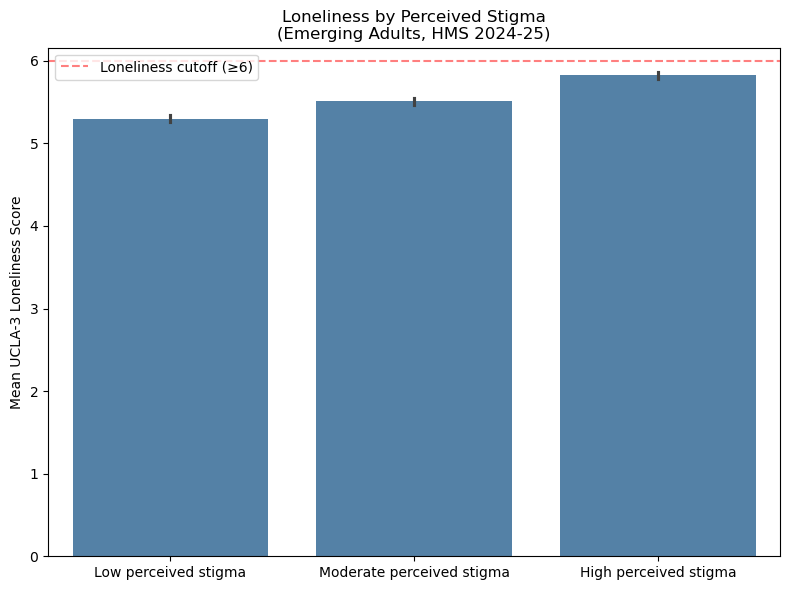

In [29]:
# bin perceived stigma into thirds
emerging_adults["perceived_stigma_cat"] = pd.qcut(
    emerging_adults["stigma_perceived"],
    q=3,
    labels=["Low perceived stigma", "Moderate perceived stigma", "High perceived stigma"]
)

# plot loneliness by perceived stigma
plt.figure(figsize=(8, 6))
sns.barplot(data=emerging_adults, x="perceived_stigma_cat", y="lonesc",
            order=["Low perceived stigma", "Moderate perceived stigma", "High perceived stigma"],
            color="steelblue", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness by Perceived Stigma\n(Emerging Adults, HMS 2024-25)")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score")
plt.legend()
plt.tight_layout()
plt.show()